In [1]:
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

train_df = pd.read_csv("preprocessed_train_final.csv")
test_df  = pd.read_csv("preprocessed_test_final.csv")
train_df_2 = pd.read_csv("preprocessed_train_LSH.csv")


c:\Users\ilker\anaconda3\envs\torchgpu\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\ilker\AppData\Local\Temp\ipykernel_25676\3455001347.py:6: DtypeWarning: Columns (0: product_id) have mixed types. Specify dtype option on import or set low_memory=False.
  test_df  = pd.read_csv("preprocessed_test_final.csv")


In [2]:
train_df.head(5)

,product_id,product_text,category,product_text_clean,dominant_category,purity,total_cnt,canon_text,text_for_model,char_len,...,is_coarse,desc_token,template_key_ref,grank,cat_cnt,cap_cat,rank_cat,gsize,cap_key,rank_key
0,106588455,Deniz Feneri Iskele Kanvas Tablo 180x60cm,Tablo,deniz feneri iskele kanvas tablo 180x60cm,Tablo,1.0,1.0,deniz feneri iskele kanvas tablo 180x60cm,deniz feneri iskele kanvas tablo 180x60cm,41,...,False,NaN,deniz feneri iskele,2,25451,8000,0,4,999999999,0
1,85876069,Opel Corsa Serisi Silver-gold Model Ön Arka Ot...,Oto Koltuk Kılıfı,opel corsa serisi silver gold model ön arka ot...,Oto Koltuk Kılıfı,1.0,1.0,opel corsa serisi silver gold model on arka ot...,opel corsa serisi silver gold model ön arka ot...,61,...,False,NaN,opel corsa,9,18394,12000,0,110,999999999,0
2,84858509,Ilk Kitaplarım Şekiller,Bebek & Aktivite Oyuncakları,ilk kitaplarım şekiller,Bebek & Aktivite Oyuncakları,1.0,1.0,ilk kitaplarim sekiller,ilk kitaplarım şekiller,23,...,False,NaN,ilk kitaplarim,1,2014,999999999,0,3,999999999,0
3,54853260,Yeşil Nokta Desen Mendilli Klasik Kravat Kk10027,Kravat,yeşil nokta desen mendilli klasik kravat kk10027,Kravat,1.0,1.0,yesil nokta desen mendilli klasik kravat kk10027,yeşil nokta desen mendilli klasik kravat kk10027,48,...,False,NaN,nokta desen,78,5259,12000,0,123,999999999,0
4,198720781,Mor Zeminde Pembe Yuvarlak Desenli Dekoratif (...,Fon Perde,mor zeminde pembe yuvarlak desenli dekoratif t...,Fon Perde,1.0,2.0,mor zeminde pembe yuvarlak desenli dekoratif t...,mor zeminde pembe yuvarlak desenli dekoratif t...,72,...,False,NaN,zeminde yuvarlak dekoratif,20,19263,12000,0,16,999999999,0


In [3]:
train_df.columns

Index(['product_id', 'product_text', 'category', 'product_text_clean',
       'dominant_category', 'purity', 'total_cnt', 'canon_text',
       'text_for_model', 'char_len', 'tok_cnt', 'is_junk', 'cluster_id',
       'sample_weight', 'main_category', 'hash_text', 'fold2', 'mismatch_oof',
       'pred_category_oof', 'gap_oof', 'margin_oof', 'flag_suspect',
       'category_fixed', 'main_category_old', 'template_key', 'cnt',
       'is_coarse', 'desc_token', 'template_key_ref', 'grank', 'cat_cnt',
       'cap_cat', 'rank_cat', 'gsize', 'cap_key', 'rank_key'],
      dtype='str')

In [4]:


# Choose text column
TEXT_COL = "text_for_model"

LABEL_TRAIN = "category_fixed"

train_df[TEXT_COL] = train_df[TEXT_COL].fillna("").astype(str)
test_df[TEXT_COL]  = test_df[TEXT_COL].fillna("").astype(str)

print("Train:", train_df.shape, "| Test:", test_df.shape)
print("Train label col:", LABEL_TRAIN, "| Text col:", TEXT_COL)


Train: (2872653, 36) | Test: (1082903, 12)
Train label col: category_fixed | Text col: text_for_model


In [5]:
test_df = test_df.dropna(subset="category").reset_index(drop=True)


In [7]:
from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.preprocessing import LabelEncoder
from scipy.sparse import hstack

# Light clean (punct->space) for hashing model
def to_hash_text(s: pd.Series) -> pd.Series:
    return (s.str.lower()
              .str.replace(r"[^\w\sğüşöçıİĞÜŞÖÇ]", " ", regex=True)
              .str.replace(r"\s+", " ", regex=True)
              .str.strip())

train_df["hash_text"] = to_hash_text(train_df[TEXT_COL])
test_df["hash_text"]    = to_hash_text(test_df[TEXT_COL])

word_vec = HashingVectorizer(
    n_features=2**19, alternate_sign=False, norm="l2",
    analyzer="word", ngram_range=(1,2), lowercase=False
)
char_vec = HashingVectorizer(
    n_features=2**18, alternate_sign=False, norm="l2",
    analyzer="char_wb", ngram_range=(3,5), lowercase=False
)

def X_transform(text_series):
    return hstack([word_vec.transform(text_series), char_vec.transform(text_series)], format="csr")

# Label encoding
le = LabelEncoder()
y_train = le.fit_transform(train_df[LABEL_TRAIN].astype(str).values)
y_test  = le.transform(test_df["category"].astype(str).values)  # assumes no new categories

n_classes = len(le.classes_)
print("Classes:", n_classes)


Classes: 1140


In [ ]:
from sklearn.linear_model import SGDClassifier
from scipy.special import logsumexp
import numpy as np
from tqdm.auto import tqdm

def batch_logloss_from_scores(S, y, sample_weight=None):
    """
    Multi-class log-loss computed from raw scores S (decision_function output).
    loss_i = - (s_true - logsumexp(scores))
    """
    if S.ndim == 1:  # binary guard
        S = np.vstack([-S, S]).T

    lse = logsumexp(S, axis=1)
    s_true = S[np.arange(len(y)), y]
    loss = -(s_true - lse)

    if sample_weight is None:
        return float(loss.mean())
    sw = sample_weight.astype(np.float64)
    return float(np.sum(sw * loss) / np.sum(sw))

clf = SGDClassifier(
    loss="log_loss",
    alpha=5e-6,
    penalty="l2",
    max_iter=1,
    tol=None,
    n_jobs=-1,
    random_state=42,
    average=True
)

BATCH = 50_000
EPOCHS = 2
PRINT_EVERY = 20   # print every N batches (e.g., 10, 20, 50)
rng = np.random.RandomState(42)

idx = np.arange(len(train_df))
classes_int = np.arange(n_classes, dtype=np.int32)

global_step = 0
running_loss = 0.0
running_w = 0.0

for ep in range(EPOCHS):
    rng.shuffle(idx)
    for start in tqdm(range(0, len(idx), BATCH), desc=f"Train epoch {ep+1}/{EPOCHS}"):
        b = idx[start:start+BATCH]

        Xb = X_transform(train_df["hash_text"].iloc[b])
        yb = y_train[b]
        wb = train_df["sample_weight"].iloc[b].values.astype(np.float32)

        # update
        if ep == 0 and start == 0:
            clf.partial_fit(Xb, yb, classes=classes_int, sample_weight=wb)
        else:
            clf.partial_fit(Xb, yb, sample_weight=wb)

        global_step += 1

        # print loss sometimes (on current batch, after update)
        if global_step % PRINT_EVERY == 0:
            S = clf.decision_function(Xb)
            loss_val = batch_logloss_from_scores(S, yb, wb)

            # optional: batch accuracy for sanity
            if np.ndim(S) == 1:
                S = np.vstack([-S, S]).T
            pred_b = S.argmax(axis=1)
            acc_b = float((pred_b == yb).mean())

            # running weighted loss (rough)
            running_loss = 0.9 * running_loss + 0.1 * loss_val
            print(f"[ep {ep+1}] step {global_step:>6} | batch_logloss={loss_val:.4f} | batch_acc={acc_b:.4f} | smooth_loss={running_loss:.4f}")

print("Training done.")


Train epoch 1/2:  34%|███▍      | 20/58 [46:57<2:16:16, 215.16s/it]

[ep 1] step     20 | batch_logloss=0.7549 | batch_acc=0.8931 | smooth_loss=0.0755


Train epoch 1/2:  69%|██████▉   | 40/58 [1:39:50<1:03:11, 210.62s/it]

[ep 1] step     40 | batch_logloss=0.7583 | batch_acc=0.8962 | smooth_loss=0.1438


Train epoch 2/2:   2%|▏         | 1/58 [02:31<2:24:05, 151.68s/it]

In [2]:
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

train_df = pd.read_csv("preprocessed_train_final.csv")
test_df  = pd.read_csv("preprocessed_test_final.csv")
train_df_2 = pd.read_csv("preprocessed_train_LSH.csv")


c:\Users\ilker\anaconda3\envs\torchgpu\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\ilker\AppData\Local\Temp\ipykernel_1732\3455001347.py:6: DtypeWarning: Columns (0: product_id) have mixed types. Specify dtype option on import or set low_memory=False.
  test_df  = pd.read_csv("preprocessed_test_final.csv")


In [6]:
test_df.columns

Index(['product_id', 'product_text', 'category', 'canon_text',
       'text_for_model', 'char_len', 'tok_cnt', 'is_junk',
       'product_text_clean', 'hash_text', 'is_exact_leak',
       'train_cluster_id_if_exact'],
      dtype='str')

In [3]:
train_df = train_df.groupby('category_fixed').sample(n=1).reset_index(drop=True)
test_df = test_df.groupby('category').sample(n=1).reset_index(drop=True)

In [10]:


# Choose text column
TEXT_COL = "text_for_model"

LABEL_TRAIN = "category_fixed"

train_df[TEXT_COL] = train_df[TEXT_COL].fillna("").astype(str)
test_df[TEXT_COL]  = test_df[TEXT_COL].fillna("").astype(str)

print("Train:", train_df.shape, "| Test:", test_df.shape)
print("Train label col:", LABEL_TRAIN, "| Text col:", TEXT_COL)


Train: (1140, 36) | Test: (1140, 12)
Train label col: category_fixed | Text col: text_for_model


In [11]:
test_df = test_df.dropna(subset="category").reset_index(drop=True)


In [12]:
from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.preprocessing import LabelEncoder
from scipy.sparse import hstack

# Light clean (punct->space) for hashing model
def to_hash_text(s: pd.Series) -> pd.Series:
    return (s.str.lower()
              .str.replace(r"[^\w\sğüşöçıİĞÜŞÖÇ]", " ", regex=True)
              .str.replace(r"\s+", " ", regex=True)
              .str.strip())

train_df["hash_text"] = to_hash_text(train_df[TEXT_COL])
test_df["hash_text"]    = to_hash_text(test_df[TEXT_COL])

word_vec = HashingVectorizer(
    n_features=2**19, alternate_sign=False, norm="l2",
    analyzer="word", ngram_range=(1,2), lowercase=False
)
char_vec = HashingVectorizer(
    n_features=2**18, alternate_sign=False, norm="l2",
    analyzer="char_wb", ngram_range=(3,5), lowercase=False
)

def X_transform(text_series):
    return hstack([word_vec.transform(text_series), char_vec.transform(text_series)], format="csr")

# Label encoding
le = LabelEncoder()
y_train = le.fit_transform(train_df[LABEL_TRAIN].astype(str).values)
y_test  = le.transform(test_df["category"].astype(str).values)  # assumes no new categories

n_classes = len(le.classes_)
print("Classes:", n_classes)


Classes: 1140


In [13]:
from sklearn.linear_model import SGDClassifier
from scipy.special import logsumexp
import numpy as np
from tqdm.auto import tqdm

def batch_logloss_from_scores(S, y, sample_weight=None):
    """
    Multi-class log-loss computed from raw scores S (decision_function output).
    loss_i = - (s_true - logsumexp(scores))
    """
    if S.ndim == 1:  # binary guard
        S = np.vstack([-S, S]).T

    lse = logsumexp(S, axis=1)
    s_true = S[np.arange(len(y)), y]
    loss = -(s_true - lse)

    if sample_weight is None:
        return float(loss.mean())
    sw = sample_weight.astype(np.float64)
    return float(np.sum(sw * loss) / np.sum(sw))

clf = SGDClassifier(
    loss="log_loss",
    alpha=5e-6,
    penalty="l2",
    max_iter=1,
    tol=None,
    n_jobs=-1,
    random_state=42,
    average=True
)

BATCH = 50_000
EPOCHS = 2
PRINT_EVERY = 20   # print every N batches (e.g., 10, 20, 50)
rng = np.random.RandomState(42)

idx = np.arange(len(train_df))
classes_int = np.arange(n_classes, dtype=np.int32)

global_step = 0
running_loss = 0.0
running_w = 0.0

for ep in range(EPOCHS):
    rng.shuffle(idx)
    for start in tqdm(range(0, len(idx), BATCH), desc=f"Train epoch {ep+1}/{EPOCHS}"):
        b = idx[start:start+BATCH]

        Xb = X_transform(train_df["hash_text"].iloc[b])
        yb = y_train[b]
        wb = train_df["sample_weight"].iloc[b].values.astype(np.float32)

        # update
        if ep == 0 and start == 0:
            clf.partial_fit(Xb, yb, classes=classes_int, sample_weight=wb)
        else:
            clf.partial_fit(Xb, yb, sample_weight=wb)

        global_step += 1

        # print loss sometimes (on current batch, after update)
        if global_step % PRINT_EVERY == 0:
            S = clf.decision_function(Xb)
            loss_val = batch_logloss_from_scores(S, yb, wb)

            # optional: batch accuracy for sanity
            if np.ndim(S) == 1:
                S = np.vstack([-S, S]).T
            pred_b = S.argmax(axis=1)
            acc_b = float((pred_b == yb).mean())

            # running weighted loss (rough)
            running_loss = 0.9 * running_loss + 0.1 * loss_val
            print(f"[ep {ep+1}] step {global_step:>6} | batch_logloss={loss_val:.4f} | batch_acc={acc_b:.4f} | smooth_loss={running_loss:.4f}")

print("Training done.")


Train epoch 2/2: 100%|██████████| 1/1 [01:13<00:00, 73.53s/it]


Training done.


In [19]:
from sklearn.metrics import accuracy_score, f1_score

N = len(test_df)
pred_int = np.empty(N, dtype=np.int32)
top5_ok  = np.zeros(N, dtype=bool)
gap      = np.zeros(N, dtype=np.float32)     # top1_score - true_score
margin   = np.zeros(N, dtype=np.float32)     # top1_score - second_score

SCORE_BATCH = 20_000

for start in tqdm(range(0, N, SCORE_BATCH), desc="Scoring test"):
    end = min(start + SCORE_BATCH, N)
    Xb = X_transform(test_df["hash_text"].iloc[start:end])

    S = clf.decision_function(Xb)
    if S.ndim == 1:  # binary guard
        S = np.vstack([-S, S]).T
    S = S.astype(np.float32)

    pred = S.argmax(axis=1)
    pred_int[start:end] = pred

    # top5
    k = 5
    topk = np.argpartition(-S, kth=min(k, S.shape[1]-1), axis=1)[:, :k]
    yt = y_test[start:end]
    top5_ok[start:end] = np.any(topk == yt[:, None], axis=1)

    # scores for gap/margin
    top1 = S[np.arange(end-start), pred]
    second = np.partition(S, -2, axis=1)[:, -2]
    margin[start:end] = (top1 - second)

    true_s = S[np.arange(end-start), yt]
    gap[start:end] = (top1 - true_s)

y_pred = le.inverse_transform(pred_int)

acc1 = accuracy_score(test_df["category"].astype(str).values, y_pred)
top5 = float(top5_ok.mean())
macf = f1_score(test_df["category"].astype(str).values, y_pred, average="macro")

print("Test Top-1 Acc :", acc1)
print("Test Top-5 Acc :", top5)
print("Test Macro-F1  :", macf)

test_df["pred_category_baseline"] = y_pred
test_df["gap_baseline"] = gap
test_df["margin_baseline"] = margin
test_df["mismatch_baseline"] = (test_df["pred_category_baseline"].astype(str) != test_df["category"].astype(str))


Scoring test: 100%|██████████| 1/1 [00:45<00:00, 45.57s/it]

Test Top-1 Acc : 0.3394736842105263
Test Top-5 Acc : 0.5087719298245614
Test Macro-F1  : 0.2708646616541353


In [21]:
import json
category_mapping = json.load(open('category_map.json', 'r', encoding='utf-8'))


In [24]:
# same rule you used: map -> fillna('Diğer')
test_df["main_category"] = test_df["pred_category_baseline"].map(category_mapping).fillna("Diğer")
display(test_df["main_category"].value_counts().head(20))


main_category
Ev & Yaşam      503
Giyim           150
Kozmetik        106
Aksesuar         91
Elektronik       83
Anne & Bebek     56
Otomotiv         50
Oyuncak          38
Spor             36
Ayakkabı         27
Name: count, dtype: int64

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

# --- edit if needed ---
PRED_COL = "pred_category_baseline"
TRUE_COL = "category"

# optional: evaluate against fixed labels (NOT official)
TRUE_FIXED_COL = "category_fixed" if "category_fixed" in test_df.columns else None

TEXT_COL = "canon_text" if "canon_text" in test_df.columns else "product_text"
LABEL_TRAIN = "category_fixed" if "category_fixed" in train_df.columns else "category"


test_df = test_df.copy()

test_df[TRUE_COL] = test_df[TRUE_COL].astype(str)
test_df[PRED_COL] = test_df[PRED_COL].astype(str)

# mismatch if not present
if "mismatch_baseline" not in test_df.columns:
    test_df["mismatch_baseline"] = (test_df[PRED_COL] != test_df[TRUE_COL])

# main categories
test_df["main_true"] = test_df[TRUE_COL].map(category_mapping).fillna("Diğer")
test_df["main_pred"] = test_df[PRED_COL].map(category_mapping).fillna("Diğer")

print("Rows:", len(test_df))
print("Unique true leaf:", test_df[TRUE_COL].nunique(), "| unique pred leaf:", test_df[PRED_COL].nunique())
print("Unique main_true:", test_df["main_true"].nunique(), "| unique main_pred:", test_df["main_pred"].nunique())


Rows: 1140
Unique true leaf: 1140 | unique pred leaf: 679
Unique main_true: 10 | unique main_pred: 10


In [26]:
y_true = test_df[TRUE_COL].values
y_pred = test_df[PRED_COL].values

acc = accuracy_score(y_true, y_pred)
mac = f1_score(y_true, y_pred, average="macro")
mic = f1_score(y_true, y_pred, average="micro")
w_f = f1_score(y_true, y_pred, average="weighted")

print(f"ALL TEST | Top-1 Acc={acc:.4f} | Macro-F1={mac:.4f} | Micro-F1={mic:.4f} | Weighted-F1={w_f:.4f}")

# optional: also show against "category_fixed" if present (not official)
if TRUE_FIXED_COL:
    y_true2 = test_df[TRUE_FIXED_COL].astype(str).values
    acc2 = accuracy_score(y_true2, y_pred)
    mac2 = f1_score(y_true2, y_pred, average="macro")
    print(f"(Noise-analysis) vs category_fixed | Acc={acc2:.4f} | Macro-F1={mac2:.4f}")


ALL TEST | Top-1 Acc=0.3395 | Macro-F1=0.2709 | Micro-F1=0.3395 | Weighted-F1=0.2709


In [28]:
# train counts based on TRAIN label column
train_counts = train_df[LABEL_TRAIN].astype(str).value_counts()
test_df["train_freq"] = test_df[TRUE_COL].map(train_counts).fillna(0).astype(int)

bins = [-1, 200, 500, 2000, 10000, 10**18]
names = ["<=200", "201-500", "501-2k", "2k-10k", ">10k"]
test_df["freq_bin"] = pd.cut(test_df["train_freq"], bins=bins, labels=names)

rows = []
for b in names:
    m = (test_df["freq_bin"] == b).values
    yt = test_df.loc[m, TRUE_COL].values
    yp = test_df.loc[m, PRED_COL].values
    if len(yt) == 0:
        continue
    rows.append({
        "freq_bin": b,
        "n_test": len(yt),
        "avg_train_freq": float(test_df.loc[m, "train_freq"].mean()),
        "acc": accuracy_score(yt, yp),
        "macro_f1": f1_score(yt, yp, average="macro"),
        "micro_f1": f1_score(yt, yp, average="micro"),
    })

tail_df = pd.DataFrame(rows)
display(tail_df)


,freq_bin,n_test,avg_train_freq,acc,macro_f1,micro_f1
0,<=200,1140,1.0,0.339474,0.270865,0.339474


In [29]:
# main-level metrics
acc_main = accuracy_score(test_df["main_true"], test_df["main_pred"])
mac_main = f1_score(test_df["main_true"], test_df["main_pred"], average="macro")
print(f"MAIN-CAT | Acc={acc_main:.4f} | Macro-F1={mac_main:.4f}")

# conditional leaf accuracy given main correct
main_ok = (test_df["main_true"] == test_df["main_pred"]).values
acc_leaf_cond = accuracy_score(test_df.loc[main_ok, TRUE_COL], test_df.loc[main_ok, PRED_COL]) if main_ok.sum() else np.nan
mac_leaf_cond = f1_score(test_df.loc[main_ok, TRUE_COL], test_df.loc[main_ok, PRED_COL], average="macro") if main_ok.sum() else np.nan

print(f"LEAF | Given main correct: n={main_ok.sum()} | Acc={acc_leaf_cond:.4f} | Macro-F1={mac_leaf_cond:.4f}")

# per-main breakdown
per_main = (test_df.groupby("main_true")
            .apply(lambda g: pd.Series({
                "n": len(g),
                "leaf_acc": accuracy_score(g[TRUE_COL], g[PRED_COL]),
                "leaf_macroF1": f1_score(g[TRUE_COL], g[PRED_COL], average="macro"),
            }))
            .sort_values("n", ascending=False))
display(per_main)


MAIN-CAT | Acc=0.7000 | Macro-F1=0.6147
LEAF | Given main correct: n=798 | Acc=0.4850 | Macro-F1=0.3919


,n,leaf_acc,leaf_macroF1
main_true,,,
Ev & Yaşam,505.0,0.342574,0.247283
Giyim,141.0,0.312057,0.221341
Kozmetik,106.0,0.377358,0.263768
Aksesuar,89.0,0.269663,0.170667
Elektronik,82.0,0.402439,0.274691
Anne & Bebek,56.0,0.392857,0.253165
Otomotiv,53.0,0.339623,0.204329
Oyuncak,41.0,0.390244,0.244444
Spor,35.0,0.285714,0.183333


In [30]:
pairs = (test_df.groupby([TRUE_COL, PRED_COL])
         .size()
         .reset_index(name="cnt")
         .sort_values("cnt", ascending=False))

true_cnt = test_df[TRUE_COL].value_counts().rename("true_cnt").reset_index().rename(columns={"index": TRUE_COL})
pairs = pairs.merge(true_cnt, on=TRUE_COL, how="left")
pairs["rate_of_true"] = pairs["cnt"] / pairs["true_cnt"]

print("Top confusion pairs by COUNT:")
display(pairs.head(30))

# show high-rate confusions but avoid tiny denominators (e.g. true_cnt >= 50)
min_true = 50
pairs2 = pairs[pairs["true_cnt"] >= min_true].sort_values("rate_of_true", ascending=False)

print(f"Top confusion pairs by RATE (true_cnt>={min_true}):")
display(pairs2.head(30))


Top confusion pairs by COUNT:


,category,pred_category_baseline,cnt,true_cnt,rate_of_true
0,ADSL Modemler,ADSL Modemler,1,1,1.0
1,Abajur,Abajur,1,1,1.0
2,Abiye & Mezuniyet Elbisesi,Atlet,1,1,1.0
3,Abiye Ayakkabı,Abiye & Mezuniyet Elbisesi,1,1,1.0
4,Abiye Çanta,Spor Çantası,1,1,1.0
5,Ahşap & Metal Kesme,Endüstriyel Temizleme,1,1,1.0
6,Ahşap Boyaları&Vernik,Akrilik Boya,1,1,1.0
7,Ahşap Boyası,Avize,1,1,1.0
8,Ahşap Oyuncaklar,Saç Düzleştirici,1,1,1.0
9,Ajanda,Ajanda,1,1,1.0


Top confusion pairs by RATE (true_cnt>=50):


,category,pred_category_baseline,cnt,true_cnt,rate_of_true


,coverage,n_kept,acc_on_kept,margin_threshold
0,1.00,1140,0.339474,0.001103
1,0.99,1128,0.343085,0.014035
2,0.98,1117,0.343778,0.023434
3,0.95,1083,0.351801,0.064130
4,0.90,1026,0.365497,0.146247
5,0.80,912,0.398026,0.315971
6,0.70,798,0.431078,0.509026
7,0.50,570,0.515789,1.068993


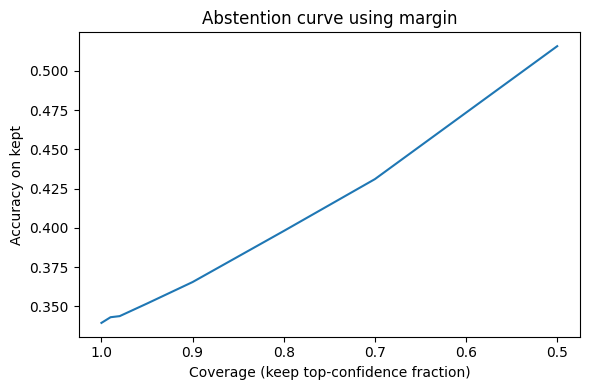

In [31]:
assert "margin_baseline" in test_df.columns, "Need margin_baseline to build abstention curve"

marg = test_df["margin_baseline"].values.astype(float)
ok = (test_df[PRED_COL].values == test_df[TRUE_COL].values)

# sort by confidence descending
order = np.argsort(-marg)
marg_s = marg[order]
ok_s = ok[order]

# evaluate at these coverages
coverages = [1.00, 0.99, 0.98, 0.95, 0.90, 0.80, 0.70, 0.50]
rows = []
N = len(test_df)

for c in coverages:
    k = int(N * c)
    k = max(1, k)
    acc_c = float(ok_s[:k].mean())
    thr = float(marg_s[k-1])
    rows.append({"coverage": c, "n_kept": k, "acc_on_kept": acc_c, "margin_threshold": thr})

abst_df = pd.DataFrame(rows)
display(abst_df)

# plot coverage vs accuracy
plt.figure(figsize=(6,4))
plt.plot(abst_df["coverage"], abst_df["acc_on_kept"])
plt.gca().invert_xaxis()
plt.xlabel("Coverage (keep top-confidence fraction)")
plt.ylabel("Accuracy on kept")
plt.title("Abstention curve using margin")
plt.tight_layout()
plt.show()


In [32]:
# Your suspect rule (as you defined)
assert "gap_baseline" in test_df.columns and "margin_baseline" in test_df.columns

suspect = (test_df["mismatch_baseline"].values &
           (test_df["gap_baseline"].values > 0.5) &
           (test_df["margin_baseline"].values > 0.3))

test_df["flag_suspect"] = suspect
print("Suspect rate:", test_df["flag_suspect"].mean(), "| count:", int(test_df["flag_suspect"].sum()))

# metrics excluding suspect (still evaluated against original labels, just shows sensitivity)
eval_slice(~test_df["flag_suspect"].values, "NOT-SUSPECT")
eval_slice(test_df["flag_suspect"].values, "SUSPECT")

# per-main suspect rate
sus_by_main = (test_df.groupby("main_true")["flag_suspect"].mean().sort_values(ascending=False))
display(sus_by_main)


Suspect rate: 0.47719298245614034 | count: 544
NOT-SUSPECT        | n=    596 | acc=0.6493 | macroF1=0.5312
SUSPECT            | n=    544 | acc=0.0000 | macroF1=0.0000


main_true
Otomotiv        0.528302
Spor            0.514286
Oyuncak         0.512195
Giyim           0.496454
Aksesuar        0.483146
Ev & Yaşam      0.479208
Ayakkabı        0.468750
Kozmetik        0.452830
Anne & Bebek    0.446429
Elektronik      0.414634
Name: flag_suspect, dtype: float64

In [33]:
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# --- sanity checks ---
for name in ["clf", "le", "X_transform"]:
    if name not in globals():
        raise ValueError(f"Missing {name} in memory. Train the baseline first (clf, le, X_transform).")

if "hash_text" not in test_df.columns:
    raise ValueError("test_df needs 'hash_text' (run your hashing text preprocessing first).")

N = len(test_df)
K = 5
BATCH = 20_000

top1 = np.empty(N, dtype=object)
top3 = np.empty(N, dtype=object)  # each entry will be a list of 3 labels
top5 = np.empty(N, dtype=object)  # each entry will be a list of 5 labels

top3_scores = np.empty(N, dtype=object)  # list of 3 scores
top5_scores = np.empty(N, dtype=object)  # list of 5 scores

classes = le.classes_  # numpy array of label strings

for start in tqdm(range(0, N, BATCH), desc="Top-k scoring"):
    end = min(start + BATCH, N)
    Xb = X_transform(test_df["hash_text"].iloc[start:end])

    S = clf.decision_function(Xb)
    if S.ndim == 1:  # binary guard
        S = np.vstack([-S, S]).T

    # get top-K indices (unsorted)
    idx_topk = np.argpartition(-S, kth=K-1, axis=1)[:, :K]
    scr_topk = S[np.arange(end-start)[:, None], idx_topk]

    # sort the top-K by score descending
    order = np.argsort(-scr_topk, axis=1)
    idx_sorted = idx_topk[np.arange(end-start)[:, None], order]
    scr_sorted = scr_topk[np.arange(end-start)[:, None], order]

    labels_sorted = classes[idx_sorted]  # shape (batch, K)

    # fill outputs
    top1[start:end] = labels_sorted[:, 0]

    for i in range(end-start):
        top3[start+i] = labels_sorted[i, :3].tolist()
        top5[start+i] = labels_sorted[i, :5].tolist()
        top3_scores[start+i] = scr_sorted[i, :3].tolist()
        top5_scores[start+i] = scr_sorted[i, :5].tolist()

test_df["pred_top1"] = top1
test_df["pred_top3"] = top3
test_df["pred_top5"] = top5
test_df["score_top3"] = top3_scores
test_df["score_top5"] = top5_scores

display(test_df[["pred_top1", "pred_top3", "pred_top5"]].head(10))


Top-k scoring: 100%|██████████| 1/1 [00:47<00:00, 47.48s/it]


,pred_top1,pred_top3,pred_top5
0,ADSL Modemler,"[ADSL Modemler, Monitör, Masaüstü Organizer]","[ADSL Modemler, Monitör, Masaüstü Organizer, K..."
1,Abajur,"[Abajur, Gümüş Halhal, Yapışkanlı Folyo]","[Abajur, Gümüş Halhal, Yapışkanlı Folyo, Pudra..."
2,Atlet,"[Atlet, Abiye & Mezuniyet Elbisesi, Abiye Çanta]","[Atlet, Abiye & Mezuniyet Elbisesi, Abiye Çant..."
3,Abiye & Mezuniyet Elbisesi,"[Abiye & Mezuniyet Elbisesi, Büyük Beden Abiye...","[Abiye & Mezuniyet Elbisesi, Büyük Beden Abiye..."
4,Spor Çantası,"[Spor Çantası, Lazer Yazıcı, Altın Küpe]","[Spor Çantası, Lazer Yazıcı, Altın Küpe, Ceket..."
5,Endüstriyel Temizleme,"[Endüstriyel Temizleme, Kaynak Makineleri, Yol...","[Endüstriyel Temizleme, Kaynak Makineleri, Yol..."
6,Akrilik Boya,"[Akrilik Boya, Elde Bulaşık Deterjanı, Zeytiny...","[Akrilik Boya, Elde Bulaşık Deterjanı, Zeytiny..."
7,Avize,"[Avize, Akrilik Boya, Kuru Boya Kalemi]","[Avize, Akrilik Boya, Kuru Boya Kalemi, Kamp L..."
8,Saç Düzleştirici,"[Saç Düzleştirici, Çocuk Puzzle & Yapboz, Emzi...","[Saç Düzleştirici, Çocuk Puzzle & Yapboz, Emzi..."
9,Ajanda,"[Ajanda, Lastik, Yılbaşı Ağacı]","[Ajanda, Lastik, Yılbaşı Ağacı, Uzaktan Kumand..."


In [34]:
if "category" in test_df.columns:
    y_true = test_df["category"].astype(str).values
    top3_ok = np.array([y_true[i] in test_df["pred_top3"].iloc[i] for i in range(len(test_df))])
    top5_ok = np.array([y_true[i] in test_df["pred_top5"].iloc[i] for i in range(len(test_df))])

    print("Top-3 accuracy:", top3_ok.mean())
    print("Top-5 accuracy:", top5_ok.mean())


Top-3 accuracy: 0.46228070175438596
Top-5 accuracy: 0.5087719298245614


In [35]:
import os, json, numpy as np, pandas as pd
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    DataCollatorWithPadding, TrainingArguments, Trainer
)
from sklearn.metrics import f1_score, accuracy_score

In [36]:
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# ---- columns (edit if yours differ) ----
TEXT_COL = "text_for_model"          # or "text_for_model"
LABEL_COL = "category_fixed"     # your fixed train labels
WEIGHT_COL = "sample_weight"     # your downweight column

# flags (optional)
JUNK_COL = "is_junk"             # optional
LEAK_COL = "is_exact_leak"       # optional

# ---- model ----
MODEL_NAME = "Trendyol/tyroberta"  # strong for TR+EN mix
# MODEL_NAME = "dbmdz/bert-base-turkish-cased"  # also good

MAX_LEN = 64  # titles are short; 64 or 80 is usually enough
SEED = 42

In [39]:
train_df['product_id'] = train_df['product_id'].astype(str)
test_df['product_id'] = test_df['product_id'].astype(str)

train_ds = Dataset.from_pandas(train_df)
test_ds   = Dataset.from_pandas(test_df)


In [40]:
# sanity: required columns
for c in [TEXT_COL, LABEL_COL]:
    if c not in train_ds.column_names:
        raise ValueError(f"train missing required column: {c}")
for c in [TEXT_COL, "category"]:  # test has ground truth category in your case
    if c not in test_ds.column_names:
        raise ValueError(f"test missing required column: {c}")

# add weights if missing
if WEIGHT_COL not in train_ds.column_names:
    train_ds = train_ds.add_column(WEIGHT_COL, [1.0] * len(train_ds))
if WEIGHT_COL not in test_ds.column_names:
    test_ds = test_ds.add_column(WEIGHT_COL, [1.0] * len(test_ds))

# optional: filter train
if JUNK_COL in train_ds.column_names:
    train_ds = train_ds.filter(lambda x: not x[JUNK_COL])
if LEAK_COL in train_ds.column_names:
    train_ds = train_ds.filter(lambda x: not x[LEAK_COL])

print("Train after filtering:", len(train_ds))
print("Test size:", len(test_ds))


Filter: 100%|██████████| 1140/1140 [00:00<00:00, 15235.69 examples/s]

Train after filtering: 1140
Test size: 1140


In [41]:
# Build label list from train (string labels)
labels = sorted(set(train_ds[LABEL_COL]))
label2id = {lab:i for i, lab in enumerate(labels)}
id2label = {i:lab for lab, i in label2id.items()}

num_labels = len(labels)
print("num_labels:", num_labels)

# Map to integer labels for train
def map_train_label(batch):
    return {"labels": [label2id[x] for x in batch[LABEL_COL]]}

train_ds = train_ds.map(map_train_label, batched=True, desc="Mapping train labels")

# Map test "category" into label ids (for evaluation). If some label not found -> set -1.
def map_test_label(batch):
    out = []
    for x in batch["category"]:
        out.append(label2id.get(x, -1))
    return {"labels": out}

test_ds = test_ds.map(map_test_label, batched=True, desc="Mapping test labels")

# (Optional) check unknown labels in test
unknown = sum([1 for x in test_ds["labels"] if x == -1])
print("Unknown test labels (not in train):", unknown)


num_labels: 1140


Mapping test labels: 100%|██████████| 1140/1140 [00:00<00:00, 68646.55 examples/s]

Unknown test labels (not in train): 0


In [42]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

def tokenize(batch):
    return tokenizer(
        batch[TEXT_COL],
        truncation=True,
        max_length=MAX_LEN
    )

train_tok = train_ds.map(tokenize, batched=True, remove_columns=[], desc="Tokenizing train")
test_tok  = test_ds.map(tokenize, batched=True, remove_columns=[], desc="Tokenizing test")

# Keep only columns needed by Trainer + your weight
keep_cols = {"input_ids", "attention_mask", "labels", WEIGHT_COL}
if "token_type_ids" in train_tok.column_names:
    keep_cols.add("token_type_ids")

train_tok = train_tok.remove_columns([c for c in train_tok.column_names if c not in keep_cols])
test_tok  = test_tok.remove_columns([c for c in test_tok.column_names if c not in keep_cols])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


Tokenizing test: 100%|██████████| 1140/1140 [00:00<00:00, 16281.35 examples/s]


In [43]:
import torch
import torch.nn.functional as F

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        weights = inputs.pop(WEIGHT_COL, None)
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        # Ignore unknown test labels (-1) safely (mainly relevant during eval)
        if labels is not None and (labels.min() < 0):
            mask = labels >= 0
            logits = logits[mask]
            labels = labels[mask]
            if weights is not None:
                weights = weights[mask]

        loss_vec = F.cross_entropy(logits, labels, reduction="none")

        if weights is None:
            loss = loss_vec.mean()
        else:
            weights = weights.to(loss_vec.dtype)
            loss = (loss_vec * weights).sum() / (weights.sum() + 1e-12)

        return (loss, outputs) if return_outputs else loss


In [44]:
def topk_acc(logits, labels, k=5):
    # labels may contain -1 (unknown); ignore them
    labels = np.asarray(labels)
    mask = labels >= 0
    if mask.sum() == 0:
        return np.nan
    logits = logits[mask]
    labels = labels[mask]
    topk = np.argpartition(-logits, kth=min(k, logits.shape[1]-1), axis=1)[:, :k]
    return float(np.mean([labels[i] in topk[i] for i in range(len(labels))]))

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)

    labels = np.asarray(labels)
    mask = labels >= 0
    logits = logits[mask]
    labels = labels[mask]
    preds = preds[mask]

    out = {}
    out["acc"] = accuracy_score(labels, preds)
    out["macro_f1"] = f1_score(labels, preds, average="macro")
    out["top3_acc"] = topk_acc(logits, labels, k=3)
    out["top5_acc"] = topk_acc(logits, labels, k=5)
    return out


In [45]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

# A100: prefer bf16
args = TrainingArguments(
    output_dir="bert_taxonomy_out",
    seed=SEED,

    # train
    num_train_epochs=1,                 # start with 1 full epoch; go 2 if time allows
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.06,

    per_device_train_batch_size=64,     # A100 20GB + MAX_LEN=64 usually OK
    per_device_eval_batch_size=128,
    gradient_accumulation_steps=1,

    bf16=True,                          # A100 supports bf16 well
    fp16=False,

    evaluation_strategy="steps",
    eval_steps=2000,                    # adjust based on dataset size
    logging_steps=200,
    save_steps=2000,
    save_total_limit=2,

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    report_to="none",                   # change to "tensorboard" if you want
)

trainer = WeightedTrainer(
    model=model,
    args=args,
    train_dataset=train_tok,
    eval_dataset=test_tok,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at Trendyol/tyroberta and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
c:\Users\ilker\anaconda3\envs\torchgpu\Lib\site-packages\transformers\training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
C:\Users\ilker\AppData\Local\Temp\ipykernel_26968\2730906804.py:39: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedTrainer.__init__`. Use `processing_class` instead.
  trainer = WeightedTrainer(


In [46]:
train_result = trainer.train()
print(train_result)

eval_result = trainer.evaluate()
print(eval_result)

# Save label mapping (handy for later inference)
with open("bert_taxonomy_out/label2id.json", "w", encoding="utf-8") as f:
    json.dump(label2id, f, ensure_ascii=False, indent=2)


Step,Training Loss,Validation Loss


TrainOutput(global_step=18, training_loss=7.0758107503255205, metrics={'train_runtime': 13.2542, 'train_samples_per_second': 86.011, 'train_steps_per_second': 1.358, 'total_flos': 17445164161248.0, 'train_loss': 7.0758107503255205, 'epoch': 1.0})


{'eval_loss': 7.049472332000732, 'eval_acc': 0.0008771929824561404, 'eval_macro_f1': 0.0004385964912280702, 'eval_top3_acc': 0.007017543859649123, 'eval_top5_acc': 0.008771929824561403, 'eval_runtime': 3.3687, 'eval_samples_per_second': 338.413, 'eval_steps_per_second': 2.672, 'epoch': 1.0}


In [47]:
import numpy as np

def predict_texts(texts, topk=5):
    enc = tokenizer(texts, truncation=True, max_length=MAX_LEN, padding=True, return_tensors="pt")
    enc = {k:v.to(trainer.model.device) for k,v in enc.items()}
    with torch.no_grad():
        logits = trainer.model(**enc).logits.detach().cpu().numpy()

    top_idx = np.argpartition(-logits, kth=min(topk, logits.shape[1]-1), axis=1)[:, :topk]
    # sort within topk
    top_scores = logits[np.arange(len(texts))[:,None], top_idx]
    order = np.argsort(-top_scores, axis=1)
    top_idx = top_idx[np.arange(len(texts))[:,None], order]
    top_scores = top_scores[np.arange(len(texts))[:,None], order]

    top_labels = [[id2label[i] for i in row] for row in top_idx]
    return top_labels, top_scores.tolist()

# example
labels5, scores5 = predict_texts(["tasarım göz sallantılı kolye"], topk=5)
print(labels5[0])
print(scores5[0])


['Köpek Kıyafeti', 'Blender Yedek Parça', 'Tesettür Yelek', 'Gelinlik', 'Abiye Ayakkabı']
[0.71484375, 0.66796875, 0.59765625, 0.58203125, 0.58203125]


In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

# ---- edit if needed ----
TEXT_COL = "text_for_model"
TRUE_COL = "category"

BASE_PRED_COL = "pred_category_baseline"
if "pred_top1" in test_df.columns:  # if you used the top-k code, pred_top1 exists
    BASE_PRED_COL = "pred_top1"

# leakage flag
if "is_exact_leak" not in test_df.columns:
    train_canon_set = set(train_df[TEXT_COL].fillna("").astype(str).values)
    test_df["is_exact_leak"] = test_df[TEXT_COL].fillna("").astype(str).isin(train_canon_set)

# main-category mapping
test_df["main_true"] = test_df[TRUE_COL].astype(str).map(category_mapping).fillna("Diğer")

print("Test rows:", len(test_df))
print("Overlap rate:", test_df["is_exact_leak"].mean())
print("Using baseline pred col:", BASE_PRED_COL)


Test rows: 1140
Overlap rate: 0.0
Using baseline pred col: pred_top1


In [50]:
import numpy as np
from tqdm.auto import tqdm

# sanity checks
for obj in ["trainer", "test_tok", "id2label"]:
    if obj not in globals():
        raise ValueError(f"Missing {obj}. Train BERT first and keep trainer/test_tok/id2label in memory.")

# Get logits from Trainer (fast and robust)
pred_out = trainer.predict(test_tok)
logits = pred_out.predictions
labels = pred_out.label_ids

# Build top-k
K5 = 5
top5_idx = np.argpartition(-logits, kth=min(K5, logits.shape[1]-1), axis=1)[:, :K5]
top5_scr = logits[np.arange(len(logits))[:, None], top5_idx]
order = np.argsort(-top5_scr, axis=1)
top5_idx = top5_idx[np.arange(len(logits))[:, None], order]
top5_scr = top5_scr[np.arange(len(logits))[:, None], order]

# top1
pred_id = top5_idx[:, 0]
pred_label = np.array([id2label[int(i)] for i in pred_id], dtype=object)

# top3/top5 labels (lists)
top3_label = [[id2label[int(i)] for i in row[:3]] for row in top5_idx]
top5_label = [[id2label[int(i)] for i in row[:5]] for row in top5_idx]

# attach to test_df
test_df["pred_category_bert"] = pred_label
test_df["pred_top3_bert"] = top3_label
test_df["pred_top5_bert"] = top5_label
test_df["margin_bert"] = (top5_scr[:, 0] - top5_scr[:, 1]).astype(np.float32)

test_df["main_pred_bert"] = test_df["pred_category_bert"].map(category_mapping).fillna("Diğer")
test_df["main_pred_baseline"] = test_df[BASE_PRED_COL].astype(str).map(category_mapping).fillna("Diğer")

display(test_df[[TRUE_COL, BASE_PRED_COL, "pred_category_bert"]].head(10))


,category,pred_top1,pred_category_bert
0,ADSL Modemler,ADSL Modemler,Diş Fırçalık
1,Abajur,Abajur,Kaş Sabitleyici
2,Abiye & Mezuniyet Elbisesi,Atlet,Çay Kaşığı
3,Abiye Ayakkabı,Abiye & Mezuniyet Elbisesi,Roll-on ve Stick
4,Abiye Çanta,Spor Çantası,Kaş Sabitleyici
5,Ahşap & Metal Kesme,Endüstriyel Temizleme,Tansiyon Aleti
6,Ahşap Boyaları&Vernik,Akrilik Boya,Saç Kremi
7,Ahşap Boyası,Avize,Oto Branda
8,Ahşap Oyuncaklar,Saç Düzleştirici,Bant & Bant Makinesi
9,Ajanda,Ajanda,Fotokopi ve Baskı Kağıtları


In [52]:
train_df.shape, test_df.shape

((1140, 36), (1140, 33))

In [53]:
print(f"mask_all: {mask_all.sum()}")
print(f"mask_overlap: {mask_overlap.sum()}")
print(f"mask_nonover: {mask_nonover.sum()}")

mask_all: 1140
mask_overlap: 0
mask_nonover: 1140


In [57]:
def eval_pack(df, pred_col, top3_col=None, top5_col=None, main_pred_col=None, name="model", mask=None):
    if mask is None:
        mask = np.ones(len(df), dtype=bool)

    yt = df.loc[mask, TRUE_COL].astype(str).values
    yp = df.loc[mask, pred_col].astype(str).values

    out = {"model": name, "split": "ALL" if mask.sum()==len(df) else f"n={mask.sum()}"}

    out["top1_acc"] = accuracy_score(yt, yp)
    out["macro_f1"] = f1_score(yt, yp, average="macro")
    out["micro_f1"] = f1_score(yt, yp, average="micro")
    out["weighted_f1"] = f1_score(yt, yp, average="weighted")

    # top-k acc if lists exist
    if top3_col is not None:
        out["top3_acc"] = float(np.mean([yt[i] in df.loc[mask, top3_col].iloc[i] for i in range(len(yt))]))
    else:
        out["top3_acc"] = np.nan

    if top5_col is not None:
        out["top5_acc"] = float(np.mean([yt[i] in df.loc[mask, top5_col].iloc[i] for i in range(len(yt))]))
    else:
        out["top5_acc"] = np.nan

    # main-category metrics
    if main_pred_col is not None:
        mt = df.loc[mask, "main_true"].astype(str).values
        mp = df.loc[mask, main_pred_col].astype(str).values
        out["main_acc"] = accuracy_score(mt, mp)
        out["main_macro_f1"] = f1_score(mt, mp, average="macro")
    else:
        out["main_acc"] = np.nan
        out["main_macro_f1"] = np.nan

    return out

mask_all = np.ones(len(test_df), dtype=bool)
mask_overlap = test_df["is_exact_leak"].values
mask_nonover = ~mask_overlap

rows = []
# baseline
rows.append(eval_pack(test_df, BASE_PRED_COL,
                      top3_col="pred_top3" if "pred_top3" in test_df.columns else None,
                      top5_col="pred_top5" if "pred_top5" in test_df.columns else None,
                      main_pred_col="main_pred_baseline",
                      name="Baseline-Hash+SGD", mask=mask_all))

# bert
rows.append(eval_pack(test_df, "pred_category_bert",
                      top3_col="pred_top3_bert",
                      top5_col="pred_top5_bert",
                      main_pred_col="main_pred_bert",
                      name="BERT", mask=mask_all))


cmp = pd.DataFrame(rows)
# add split names for nice display
cmp["split"] = ["ALL-BASELINE", "ALL-BERT"]
display(cmp)


,model,split,top1_acc,macro_f1,micro_f1,weighted_f1,top3_acc,top5_acc,main_acc,main_macro_f1
0,Baseline-Hash+SGD,ALL-BASELINE,0.339474,0.270865,0.339474,0.270865,0.462281,0.508772,0.700000,0.614731
1,BERT,ALL-BERT,0.000877,0.000439,0.000877,0.000439,0.007018,0.008772,0.245614,0.103893


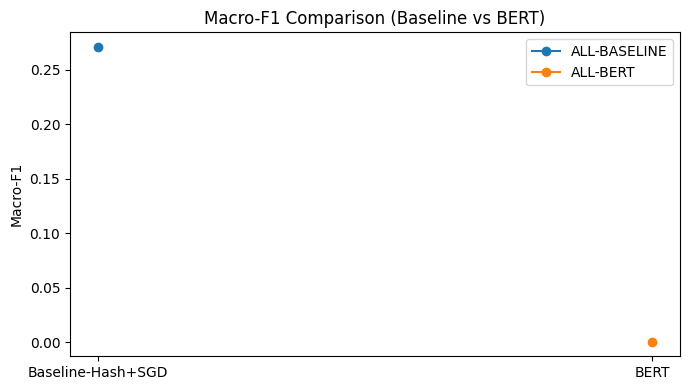

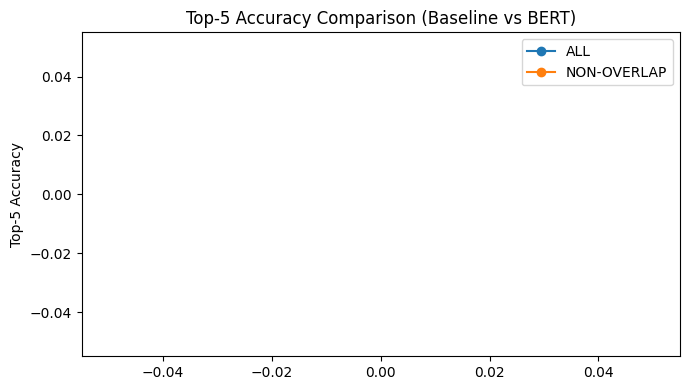

In [58]:
plot_df = cmp[(cmp["split"].isin(["ALL-BASELINE", "ALL-BERT"]))].copy()

# Macro-F1 plot
plt.figure(figsize=(7,4))
for split in ["ALL-BASELINE", "ALL-BERT"]:
    sub = plot_df[plot_df["split"]==split]
    plt.plot(sub["model"], sub["macro_f1"], marker="o", label=split)
plt.title("Macro-F1 Comparison (Baseline vs BERT)")
plt.ylabel("Macro-F1")
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

# Top-5 plot (if available)
plt.figure(figsize=(7,4))
for split in ["ALL", "NON-OVERLAP"]:
    sub = plot_df[plot_df["split"]==split]
    plt.plot(sub["model"], sub["top5_acc"], marker="o", label=split)
plt.title("Top-5 Accuracy Comparison (Baseline vs BERT)")
plt.ylabel("Top-5 Accuracy")
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()


In [59]:
def top_confusions(df, pred_col, min_true=50, topn=25):
    tmp = df.copy()
    tmp["true"] = tmp[TRUE_COL].astype(str)
    tmp["pred"] = tmp[pred_col].astype(str)

    pairs = (tmp.groupby(["true","pred"]).size().reset_index(name="cnt"))
    true_cnt = tmp["true"].value_counts().rename("true_cnt").reset_index().rename(columns={"index":"true"})
    pairs = pairs.merge(true_cnt, on="true", how="left")
    pairs["rate_of_true"] = pairs["cnt"] / pairs["true_cnt"]

    # exclude correct pairs
    pairs = pairs[pairs["true"] != pairs["pred"]]

    by_cnt = pairs.sort_values("cnt", ascending=False).head(topn)
    by_rate = pairs[pairs["true_cnt"] >= min_true].sort_values("rate_of_true", ascending=False).head(topn)
    return by_cnt, by_rate

base_cnt, base_rate = top_confusions(test_df, BASE_PRED_COL)
bert_cnt, bert_rate = top_confusions(test_df, "pred_category_bert")

print("Baseline - top confusions by COUNT")
display(base_cnt)
print("Baseline - top confusions by RATE")
display(base_rate)

print("BERT - top confusions by COUNT")
display(bert_cnt)
print("BERT - top confusions by RATE")
display(bert_rate)


Baseline - top confusions by COUNT


,true,pred,cnt,true_cnt,rate_of_true
2,Abiye & Mezuniyet Elbisesi,Atlet,1,1,1.0
3,Abiye Ayakkabı,Abiye & Mezuniyet Elbisesi,1,1,1.0
4,Abiye Çanta,Spor Çantası,1,1,1.0
5,Ahşap & Metal Kesme,Endüstriyel Temizleme,1,1,1.0
6,Ahşap Boyaları&Vernik,Akrilik Boya,1,1,1.0
7,Ahşap Boyası,Avize,1,1,1.0
8,Ahşap Oyuncaklar,Saç Düzleştirici,1,1,1.0
10,Akrilik Boya,Kupalar,1,1,1.0
11,Aktar Ürünleri,Salça,1,1,1.0
14,Akvaryum Dekor Ve Aksesuarı,Yazarkasa ve Terazi,1,1,1.0


Baseline - top confusions by RATE


,true,pred,cnt,true_cnt,rate_of_true


BERT - top confusions by COUNT


,true,pred,cnt,true_cnt,rate_of_true
0,ADSL Modemler,Diş Fırçalık,1,1,1.0
1,Abajur,Kaş Sabitleyici,1,1,1.0
2,Abiye & Mezuniyet Elbisesi,Çay Kaşığı,1,1,1.0
3,Abiye Ayakkabı,Roll-on ve Stick,1,1,1.0
4,Abiye Çanta,Kaş Sabitleyici,1,1,1.0
5,Ahşap & Metal Kesme,Tansiyon Aleti,1,1,1.0
6,Ahşap Boyaları&Vernik,Saç Kremi,1,1,1.0
7,Ahşap Boyası,Oto Branda,1,1,1.0
8,Ahşap Oyuncaklar,Bant & Bant Makinesi,1,1,1.0
9,Ajanda,Fotokopi ve Baskı Kağıtları,1,1,1.0


BERT - top confusions by RATE


,true,pred,cnt,true_cnt,rate_of_true


In [60]:
# define correctness
test_df["base_ok"] = (test_df[BASE_PRED_COL].astype(str) == test_df[TRUE_COL].astype(str))
test_df["bert_ok"] = (test_df["pred_category_bert"].astype(str) == test_df[TRUE_COL].astype(str))

improve = test_df[(~test_df["base_ok"]) & (test_df["bert_ok"])].copy()
worsen  = test_df[(test_df["base_ok"]) & (~test_df["bert_ok"])].copy()

cols = [c for c in ["product_id","product_text","canon_text",TRUE_COL,BASE_PRED_COL,"pred_category_bert","pred_top5_bert","main_true","main_pred_baseline","main_pred_bert"] if c in test_df.columns]

print("BERT improves over baseline:", len(improve))
display(improve[cols].head(30))

print("BERT worse than baseline:", len(worsen))
display(worsen[cols].head(30))


BERT improves over baseline: 1


,product_id,product_text,canon_text,category,pred_top1,pred_category_bert,pred_top5_bert,main_true,main_pred_baseline,main_pred_bert
867,34630456,Fp8481 How We Do Tıght,fp8481 how we do tıght,Spor Tayt,Tesettür Abiye,Spor Tayt,"[Spor Tayt, Jant Kapağı, Outdoor Aksesuarları,...",Giyim,Giyim,Giyim


BERT worse than baseline: 387


,product_id,product_text,canon_text,category,pred_top1,pred_category_bert,pred_top5_bert,main_true,main_pred_baseline,main_pred_bert
0,36689693,Tl-sf1016d 16-portlu 10/100mbps Masaüstü Switch,tl-sf1016d 16-portlu 10/100mbps masaüstü switch,ADSL Modemler,ADSL Modemler,Diş Fırçalık,"[Diş Fırçalık, Seramik ve Yer Döşemeleri, Tese...",Elektronik,Elektronik,Ev & Yaşam
1,63420051,Sarı Kırçıl Gold Kaplama Helezon Abajur,sarı kırçıl gold kaplama helezon abajur,Abajur,Abajur,Kaş Sabitleyici,"[Kaş Sabitleyici, Altın Yüzük, Emzirme Sütyeni...",Ev & Yaşam,Ev & Yaşam,Kozmetik
9,145605224,2021-2022 Etkinlik Ajandası - 8 Ajanda,2021-2022 etkinlik ajandası - 8 ajanda,Ajanda,Ajanda,Fotokopi ve Baskı Kağıtları,"[Fotokopi ve Baskı Kağıtları, Şemsiye, Tabak, ...",Ev & Yaşam,Ev & Yaşam,Ev & Yaşam
12,99041088,Aktivite Masası 1 Masa 2 Sandalye,aktivite masası 1 masa 2 sandalye,Aktivite Masası & Merkezi,Aktivite Masası & Merkezi,Mutfak Masaları,"[Mutfak Masaları, Şemsiye, Hurç, Kolçaklar, Ta...",Anne & Bebek,Anne & Bebek,Ev & Yaşam
13,212422248,Dajana Gammarus Sticks 1000 Ml 375 Gr,dajana gammarus sticks 1000 ml 375 gr,Akvaryum,Akvaryum,Sıvı Yağ,"[Sıvı Yağ, Telefon Kasası, Şemsiye, Tabak, Öze...",Ev & Yaşam,Ev & Yaşam,Ev & Yaşam
15,141737282,Bmw G 310 R Gs 2016 2019 Ytx9-bs Btx9-bs Akü,bmw g 310 r gs 2016 2019 ytx9-bs btx9-bs akü,Akü,Akü,Yapay & Kuru Çiçek,"[Yapay & Kuru Çiçek, Şemsiye, Seramik ve Yer D...",Otomotiv,Otomotiv,Ev & Yaşam
17,215804646,Sf 2-a12 Akülü Vidalama Makinesi,sf 2-a12 akülü vidalama makinesi,Akülü Vidalama,Akülü Vidalama,Duvar Örtüsü,"[Duvar Örtüsü, Tabanlık, Dekoratif Obje ve Bib...",Ev & Yaşam,Ev & Yaşam,Ev & Yaşam
18,68024471,M5 Smart Bracellet Akıllı Spor Bileklik Konuşm...,m5 smart bracellet akıllı spor bileklik konuşm...,Akıllı Bileklik,Akıllı Bileklik,Mont,"[Mont, Jant Kapağı, Emzirme Sütyeni, El Çantas...",Elektronik,Elektronik,Giyim
20,129404035,A23 Duos 128 Gb Türkiye Garantili,a23 duos 128 gb türkiye garantili,Akıllı Cep Telefonu,Akıllı Cep Telefonu,Bant & Bant Makinesi,"[Bant & Bant Makinesi, Versatil Kalem, Konsol ...",Elektronik,Elektronik,Ev & Yaşam
22,85981590,Watch Kordon 42 - 44 mm Uyumlu Spor Delikli Ko...,watch kordon 42 - 44 mm uyumlu spor delikli ko...,Akıllı Saat Kordon,Akıllı Saat Kordon,Emzirme Sütyeni,"[Emzirme Sütyeni, Kaş Sabitleyici, Kablolu Hop...",Elektronik,Elektronik,Anne & Bebek


In [61]:
import joblib
from pathlib import Path
import json

SAVE_DIR = Path("saved_models/baseline_hash_sgd")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# baseline objects expected in memory: clf, le, and your vectorizer params (we can recreate HashingVectorizer from params)
joblib.dump(clf, SAVE_DIR / "sgd_clf.joblib")
joblib.dump(le,  SAVE_DIR / "label_encoder.joblib")

# store the hashing config so you can rebuild the exact same feature transform later
baseline_config = {
    "word_vec": {
        "n_features": 2**19, "alternate_sign": False, "norm": "l2",
        "analyzer": "word", "ngram_range": [1,2], "lowercase": False
    },
    "char_vec": {
        "n_features": 2**18, "alternate_sign": False, "norm": "l2",
        "analyzer": "char_wb", "ngram_range": [3,5], "lowercase": False
    },
    "text_col_used": TEXT_COL if "TEXT_COL" in globals() else None
}

with open(SAVE_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(baseline_config, f, ensure_ascii=False, indent=2)

print("Saved baseline to:", SAVE_DIR)


Saved baseline to: saved_models\baseline_hash_sgd


In [62]:
from pathlib import Path
import json

BERT_DIR = Path("saved_models/bert_model")
BERT_DIR.mkdir(parents=True, exist_ok=True)

trainer.save_model(str(BERT_DIR))      # saves model + config
tokenizer.save_pretrained(str(BERT_DIR))

# also save label mapping if you have it in memory
if "label2id" in globals():
    with open(BERT_DIR / "label2id.json", "w", encoding="utf-8") as f:
        json.dump(label2id, f, ensure_ascii=False, indent=2)
if "id2label" in globals():
    with open(BERT_DIR / "id2label.json", "w", encoding="utf-8") as f:
        json.dump({str(k): v for k, v in id2label.items()}, f, ensure_ascii=False, indent=2)

print("Saved BERT to:", BERT_DIR)


Saved BERT to: saved_models\bert_model


In [5]:
import json
category_mapping = json.load(open('category_map.json', 'r', encoding='utf-8'))

In [17]:
import numpy as np
import pandas as pd
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, f1_score

# --- columns ---
TEXT_COL = "text_for_model"  # or "text_for_model"
LEAF_TRAIN_COL = "category_fixed" if "category_fixed" in train_df.columns else "category"
LEAF_TEST_COL  = "category"

if "sample_weight" not in train_df.columns:
    train_df["sample_weight"] = 1.0

# main labels
train_df["main_true"] = train_df[LEAF_TRAIN_COL].astype(str).map(category_mapping).fillna("Diğer")
test_df["main_true"]  = test_df[LEAF_TEST_COL].astype(str).map(category_mapping).fillna("Diğer")

# hashing text (if not already created)
def to_hash_text(s: pd.Series) -> pd.Series:
    return (s.fillna("").astype(str).str.lower()
              .str.replace(r"[^\w\sğüşöçıİĞÜŞÖÇ]", " ", regex=True)
              .str.replace(r"\s+", " ", regex=True)
              .str.strip())

if "hash_text" not in train_df.columns:
    train_df["hash_text"] = to_hash_text(train_df[TEXT_COL])
if "hash_text" not in test_df.columns:
    test_df["hash_text"]  = to_hash_text(test_df[TEXT_COL])

# vectorizers
word_vec = HashingVectorizer(n_features=2**19, alternate_sign=False, norm="l2",
                             analyzer="word", ngram_range=(1,2), lowercase=False)
char_vec = HashingVectorizer(n_features=2**18, alternate_sign=False, norm="l2",
                             analyzer="char_wb", ngram_range=(3,5), lowercase=False)

def X_text(text_series: pd.Series):
    return hstack([word_vec.transform(text_series), char_vec.transform(text_series)], format="csr")

# stage-1 label encoding
le_main = LabelEncoder()
y_main = le_main.fit_transform(train_df["main_true"].values)
n_main = len(le_main.classes_)
print("Main classes:", n_main, le_main.classes_)

clf_main = SGDClassifier(loss="log_loss", alpha=5e-6, penalty="l2",
                         max_iter=5, n_jobs=-1, random_state=42, average=True)

clf_main.fit(X_text(train_df["hash_text"]), y_main,
             sample_weight=train_df["sample_weight"].values.astype(np.float32))

# stage-1 test metrics
test_main_pred = le_main.inverse_transform(clf_main.predict(X_text(test_df["hash_text"])))
test_df["main_pred_top1"] = test_main_pred

print("MAIN test acc:", accuracy_score(test_df["main_true"], test_df["main_pred_top1"]))
print("MAIN test macroF1:", f1_score(test_df["main_true"], test_df["main_pred_top1"], average="macro"))


Main classes: 10 ['Aksesuar' 'Anne & Bebek' 'Ayakkabı' 'Elektronik' 'Ev & Yaşam' 'Giyim'
 'Kozmetik' 'Otomotiv' 'Oyuncak' 'Spor']
MAIN test acc: 0.7482456140350877
MAIN test macroF1: 0.6448282874383959


c:\Users\ilker\anaconda3\envs\torchgpu\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [18]:
import numpy as np
from tqdm.auto import tqdm

def top2_main_labels_and_scores(text_series, batch=50_000):
    N = len(text_series)
    top1_lab = np.empty(N, dtype=object)
    top2_lab = np.empty(N, dtype=object)
    top1_scr = np.empty(N, dtype=np.float32)
    top2_scr = np.empty(N, dtype=np.float32)

    classes = le_main.classes_

    for start in tqdm(range(0, N, batch), desc="Top-2 main scoring"):
        end = min(start+batch, N)
        Xb = X_text(text_series.iloc[start:end])
        S = clf_main.decision_function(Xb)
        if S.ndim == 1:
            S = np.vstack([-S, S]).T

        # top2 indices (unsorted)
        idx2 = np.argpartition(-S, kth=1, axis=1)[:, :2]
        scr2 = S[np.arange(end-start)[:, None], idx2]

        # sort top2
        order = np.argsort(-scr2, axis=1)
        idx2s = idx2[np.arange(end-start)[:, None], order]
        scr2s = scr2[np.arange(end-start)[:, None], order]

        top1_lab[start:end] = classes[idx2s[:, 0]]
        top2_lab[start:end] = classes[idx2s[:, 1]]
        top1_scr[start:end] = scr2s[:, 0].astype(np.float32)
        top2_scr[start:end] = scr2s[:, 1].astype(np.float32)

    return top1_lab, top2_lab, top1_scr, top2_scr

# compute for train + test (uses predicted mains on train too, to match inference-time feature)
train_m1, train_m2, train_s1, train_s2 = top2_main_labels_and_scores(train_df["hash_text"], batch=80_000)
test_m1,  test_m2,  test_s1,  test_s2  = top2_main_labels_and_scores(test_df["hash_text"],  batch=80_000)

train_df["main_pred1"] = train_m1
train_df["main_pred2"] = train_m2
train_df["main_score1"] = train_s1
train_df["main_score2"] = train_s2

test_df["main_pred1"] = test_m1
test_df["main_pred2"] = test_m2
test_df["main_score1"] = test_s1
test_df["main_score2"] = test_s2

display(test_df[["main_pred1","main_pred2","main_score1","main_score2"]].head(10))


Top-2 main scoring: 100%|██████████| 1/1 [00:00<00:00,  9.00it/s]


,main_pred1,main_pred2,main_score1,main_score2
0,Aksesuar,Giyim,-2.411652,-2.459563
1,Ev & Yaşam,Anne & Bebek,6.194613,-5.718581
2,Giyim,Aksesuar,6.616313,-4.090340
3,Ev & Yaşam,Ayakkabı,-3.704609,-4.885143
4,Aksesuar,Ayakkabı,7.921127,-7.934340
5,Ev & Yaşam,Giyim,-4.549657,-5.818866
6,Ev & Yaşam,Anne & Bebek,1.985913,-4.378746
7,Kozmetik,Giyim,-1.298478,-4.798668
8,Oyuncak,Ev & Yaşam,-0.692447,-2.024070
9,Ev & Yaşam,Kozmetik,10.793313,-8.545000


In [19]:
train_df["hash_text_plus_main2"] = (
    train_df["hash_text"] +
    " __MAIN1__=" + train_df["main_pred1"].astype(str) +
    " __MAIN2__=" + train_df["main_pred2"].astype(str)
)
test_df["hash_text_plus_main2"] = (
    test_df["hash_text"] +
    " __MAIN1__=" + test_df["main_pred1"].astype(str) +
    " __MAIN2__=" + test_df["main_pred2"].astype(str)
)


In [20]:
def X_text_plus_scores(text_series, s1, s2):
    Xtxt = X_text(text_series)
    Xnum = csr_matrix(np.vstack([s1, s2]).T.astype(np.float32))
    return hstack([Xtxt, Xnum], format="csr")

# Choose which to use later:
USE_SCORES = True


In [21]:
# label encode leaf
le_leaf = LabelEncoder()
y_leaf = le_leaf.fit_transform(train_df[LEAF_TRAIN_COL].astype(str).values)
print("Leaf classes:", len(le_leaf.classes_))

clf_leaf = SGDClassifier(
    loss="log_loss",
    alpha=3e-6,
    penalty="l2",
    max_iter=5,
    n_jobs=-1,
    random_state=42,
    average=True
)

if USE_SCORES:
    X_leaf_train = X_text_plus_scores(train_df["hash_text_plus_main2"],
                                      train_df["main_score1"].values,
                                      train_df["main_score2"].values)
else:
    X_leaf_train = X_text(train_df["hash_text_plus_main2"])

clf_leaf.fit(X_leaf_train, y_leaf, sample_weight=train_df["sample_weight"].values.astype(np.float32))

print("Trained leaf model with TOP-2 main features.")


Leaf classes: 1140
Trained leaf model with TOP-2 main features.


c:\Users\ilker\anaconda3\envs\torchgpu\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [27]:
if USE_SCORES:
    X_leaf_test = X_text_plus_scores(test_df["hash_text_plus_main2"],
                                     test_df["main_score1"].values,
                                     test_df["main_score2"].values)
else:
    X_leaf_test = X_text(test_df["hash_text_plus_main2"])

pred_leaf_id = clf_leaf.predict(X_leaf_test)
test_df["pred_leaf_2stage_top2"] = le_leaf.inverse_transform(pred_leaf_id)

yt = test_df[LEAF_TEST_COL].astype(str).values
yp = test_df["pred_leaf_2stage_top2"].astype(str).values

acc = accuracy_score(yt, yp)
mac = f1_score(yt, yp, average="macro")
mic = f1_score(yt, yp, average="micro")
w_f = f1_score(yt, yp, average="weighted")

print(f"LEAF TEST (top-2 main features) | acc={acc:.4f} | macroF1={mac:.4f} | microF1={mic:.4f} | weightedF1={w_f:.4f}")

# conditional leaf acc if main_true is in top-2 predicted mains
main_in_top2 = (test_df["main_true"] == test_df["main_pred1"]) | (test_df["main_true"] == test_df["main_pred2"])
acc_cond = accuracy_score(test_df.loc[main_in_top2, LEAF_TEST_COL], test_df.loc[main_in_top2, "pred_leaf_2stage_top2"])
print(f"LEAF acc | given main_true in top-2: {acc_cond:.4f} (n={main_in_top2.sum()})")


LEAF TEST (top-2 main features) | acc=0.0018 | macroF1=0.0001 | microF1=0.0018 | weightedF1=0.0001
LEAF acc | given main_true in top-2: 0.0020 (n=988)


In [28]:
X_leaf_test

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 223842 stored elements and shape (1140, 786434)>

# test

In [32]:
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

def eval_leaf_topk_consistent(
    df: pd.DataFrame,
    k_list=(1,3,5),
    batch_size=50_000,
    mask=None,
    verbose=True,
):
    """
    Computes Top-k accuracy (k in k_list) + Top-1 F1s.
    Uses SAME feature construction as your training:
      - if USE_SCORES: X_text_plus_scores(text, main_score1, main_score2)
      - else: X_text(text)
    """
    if mask is None:
        mask = np.ones(len(df), dtype=bool)

    sub = df.loc[mask].copy()

    # --- true labels -> ids (safe)
    class_to_id = {c:i for i,c in enumerate(le_leaf.classes_)}
    y_true_str = sub[LEAF_TEST_COL].astype(str).values
    y_true_id = np.array([class_to_id.get(c, -1) for c in y_true_str], dtype=np.int32)

    valid = y_true_id >= 0
    sub = sub.iloc[valid].reset_index(drop=True)
    y_true_id = y_true_id[valid]

    n = len(sub)
    if n == 0:
        return {"n": 0}

    # --- counters
    hits = {k: 0 for k in k_list}
    pred_top1 = np.empty(n, dtype=np.int32)

    # prefetch numeric arrays once (faster)
    if USE_SCORES:
        s1 = sub["main_score1"].values.astype(np.float32)
        s2 = sub["main_score2"].values.astype(np.float32)

    for start in tqdm(range(0, n, batch_size), desc="Leaf Top-k eval"):
        end = min(start + batch_size, n)

        # build features EXACTLY like training
        if USE_SCORES:
            Xb = X_text_plus_scores(sub["hash_text_plus_main2"].iloc[start:end], s1[start:end], s2[start:end])
        else:
            Xb = X_text(sub["hash_text_plus_main2"].iloc[start:end])

        S = clf_leaf.decision_function(Xb)
        if S.ndim == 1:
            # binary edge case
            S = np.vstack([-S, S]).T

        yb = y_true_id[start:end]

        # top-1
        p1 = S.argmax(axis=1).astype(np.int32)
        pred_top1[start:end] = p1
        if 1 in hits:
            hits[1] += int((p1 == yb).sum())

        # top-k
        for k in k_list:
            if k == 1:
                continue
            kk = min(k, S.shape[1])
            idx = np.argpartition(-S, kth=kk-1, axis=1)[:, :kk]
            hits[k] += int(np.any(idx == yb[:, None], axis=1).sum())

    # --- build metrics
    out = {
        "n": int(n),
        "top1_acc": hits.get(1, np.nan) / n if 1 in hits else np.nan,
        "macro_f1": f1_score(y_true_id, pred_top1, average="macro"),
        "micro_f1": f1_score(y_true_id, pred_top1, average="micro"),
        "weighted_f1": f1_score(y_true_id, pred_top1, average="weighted"),
    }
    for k in k_list:
        out[f"top{k}_acc"] = hits[k] / n

    if verbose:
        print(out)

    return out


In [33]:
mask_all = np.ones(len(test_df), dtype=bool)

if "is_exact_leak" in test_df.columns:
    mask_ov = test_df["is_exact_leak"].values
    mask_no = ~mask_ov
else:
    mask_ov = None
    mask_no = None

res_all = eval_leaf_topk_consistent(test_df, k_list=(1,3,5), mask=mask_all, batch_size=50_000, verbose=False)

rows = [{"split":"ALL", **res_all}]
if mask_ov is not None:
    res_ov = eval_leaf_topk_consistent(test_df, k_list=(1,3,5), mask=mask_ov, batch_size=50_000, verbose=False)
    res_no = eval_leaf_topk_consistent(test_df, k_list=(1,3,5), mask=mask_no, batch_size=50_000, verbose=False)
    rows += [{"split":"OVERLAP", **res_ov}, {"split":"NON-OVERLAP", **res_no}]

metrics_topk = pd.DataFrame(rows)
display(metrics_topk)


Leaf Top-k eval: 100%|██████████| 1/1 [00:36<00:00, 36.49s/it]


,split,n,top1_acc,macro_f1,micro_f1,weighted_f1,top3_acc,top5_acc
0,ALL,1140,0.001754,0.000063,0.001754,0.000063,0.003509,0.007018
1,OVERLAP,0,NaN,NaN,NaN,NaN,NaN,NaN
2,NON-OVERLAP,1140,0.001754,0.000063,0.001754,0.000063,0.003509,0.007018


In [34]:
def show_topk_examples(df, n=15, k=5, seed=42):
    samp = df.sample(n=min(n, len(df)), random_state=seed).copy().reset_index(drop=True)

    if USE_SCORES:
        Xb = X_text_plus_scores(samp["hash_text_plus_main2"], 
                                samp["main_score1"].values.astype(np.float32), 
                                samp["main_score2"].values.astype(np.float32))
    else:
        Xb = X_text(samp["hash_text_plus_main2"])

    S = clf_leaf.decision_function(Xb)
    if S.ndim == 1:
        S = np.vstack([-S, S]).T

    kk = min(k, S.shape[1])
    idx = np.argpartition(-S, kth=kk-1, axis=1)[:, :kk]
    scr = S[np.arange(len(samp))[:, None], idx]
    order = np.argsort(-scr, axis=1)
    idx = idx[np.arange(len(samp))[:, None], order]

    topk_labels = [[le_leaf.classes_[int(j)] for j in row] for row in idx]

    out = samp[[TEXT_COL, LEAF_TEST_COL, "main_pred1", "main_pred2"]].copy()
    out["top5_pred"] = topk_labels
    display(out)

show_topk_examples(test_df, n=20, k=5)


,canon_text,category,main_pred1,main_pred2,top5_pred
0,ford courıer 2014-2019 2li cam rüzgarlığı,Rüzgarlıklar,Ev & Yaşam,Giyim,"[Ateşleyici & Çakmak, Fideler, Bebek Pudrası v..."
1,ruby kurşun asker düz tabak 24cm 4'lü 04rub005459,Tabak,Ev & Yaşam,Ayakkabı,"[Spor Çorap, Akvaryum Dekor Ve Aksesuarı, Biju..."
2,jotashield tex ultra su bazlı dış cephe boyası...,Dış Cephe Boyaları,Ev & Yaşam,Spor,"[Spor Çorap, Akvaryum Dekor Ve Aksesuarı, Biju..."
3,a8260 flora collection 60 parça yuvarlak yemek...,Yemek Takımı,Ev & Yaşam,Giyim,"[Spor Çorap, Tunik, Akvaryum Dekor Ve Aksesuar..."
4,kadın siyah dantel özel tasarım külot,Fantezi Külot,Giyim,Aksesuar,"[Spor Çorap, Tunik, Yapıştırıcı ve Bantlar, Ak..."
5,el örgüsü çeyizlik lif (kese),Banyo ve Duş Aksesuarları,Ev & Yaşam,Kozmetik,"[Ateşleyici & Çakmak, Fideler, Bebek Pudrası v..."
6,guldesignstore 4lü örgü koruma mint yeşili sar...,Koruyucu Tekstil,Ev & Yaşam,Aksesuar,"[Düdüklü Tencere, Bijuteri Bileklik, Köpek Aks..."
7,sweetlife royal kollu cepli tulum,Astronot Tulum,Giyim,Spor,"[Spor Çorap, Tunik, Akvaryum Dekor Ve Aksesuar..."
8,royal set 3lü,Piknik Malzemesi,Ev & Yaşam,Kozmetik,"[Düdüklü Tencere, Fideler, Ateşleyici & Çakmak..."
9,mermer kutu pirinç,Dekoratif Kutu,Ev & Yaşam,Spor,"[Spor Çorap, Tunik, Akvaryum Dekor Ve Aksesuar..."


In [36]:
import os, re, json
import numpy as np
import pandas as pd
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    DataCollatorWithPadding, TrainingArguments, Trainer
)
from sklearn.metrics import accuracy_score, f1_score
from scipy.special import logsumexp
import torch
import torch.nn.functional as F

os.environ["TOKENIZERS_PARALLELISM"] = "false"

train_df['product_id'] = train_df['product_id'].astype(str)
test_df['product_id'] = test_df['product_id'].astype(str)

train_ds = Dataset.from_pandas(train_df)
test_ds   = Dataset.from_pandas(test_df)



# ---- columns ----
TEXT_COL = "text_for_model"
LEAF_TRAIN_COL = "category_fixed"
LEAF_TEST_COL  = "category"
WEIGHT_COL = "sample_weight"

# ---- model ----
MODEL_NAME = "xlm-roberta-base"   # good for TR+EN mix
MAX_LEN = 64
SEED = 42

# ---- saving ----
SAVE_ROOT = "Trendyol/tyroberta"
os.makedirs(SAVE_ROOT, exist_ok=True)

print(train_ds)
print(test_ds)

# add weights if missing
if WEIGHT_COL not in train_ds.column_names:
    train_ds = train_ds.add_column(WEIGHT_COL, [1.0] * len(train_ds))
if WEIGHT_COL not in test_ds.column_names:
    test_ds  = test_ds.add_column(WEIGHT_COL, [1.0] * len(test_ds))

Dataset({
    features: ['product_id', 'product_text', 'category', 'product_text_clean', 'dominant_category', 'purity', 'total_cnt', 'canon_text', 'text_for_model', 'char_len', 'tok_cnt', 'is_junk', 'cluster_id', 'sample_weight', 'main_category', 'hash_text', 'fold2', 'mismatch_oof', 'pred_category_oof', 'gap_oof', 'margin_oof', 'flag_suspect', 'category_fixed', 'main_category_old', 'template_key', 'cnt', 'is_coarse', 'desc_token', 'template_key_ref', 'grank', 'cat_cnt', 'cap_cat', 'rank_cat', 'gsize', 'cap_key', 'rank_key', 'main_true', 'main_pred1', 'main_pred2', 'main_score1', 'main_score2', 'hash_text_plus_main2', 'main_pred', 'hash_text_plus_main'],
    num_rows: 1140
})
Dataset({
    features: ['product_id', 'product_text', 'category', 'canon_text', 'text_for_model', 'char_len', 'tok_cnt', 'is_junk', 'product_text_clean', 'hash_text', 'is_exact_leak', 'train_cluster_id_if_exact', 'main_true', 'main_pred_top1', 'main_pred1', 'main_pred2', 'main_score1', 'main_score2', 'hash_text_p

In [37]:
# category_mapping must exist
assert "category_mapping" in globals(), "category_mapping dict is required"

def add_main(batch, col):
    return {"main_category": [category_mapping.get(x, "Diğer") for x in batch[col]]}

train_ds = train_ds.map(lambda b: add_main(b, LEAF_TRAIN_COL), batched=True, desc="Add main to train")
test_ds  = test_ds.map(lambda b: add_main(b, LEAF_TEST_COL),  batched=True, desc="Add main to test")

print(train_ds["main_category"][:5])
print(test_ds["main_category"][:5])


Add main to test: 100%|██████████| 1140/1140 [00:00<00:00, 65707.11 examples/s]

['Elektronik', 'Ev & Yaşam', 'Giyim', 'Ayakkabı', 'Aksesuar']
['Elektronik', 'Ev & Yaşam', 'Giyim', 'Ayakkabı', 'Aksesuar']


In [38]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
collator = DataCollatorWithPadding(tokenizer)

def tokenize(batch):
    return tokenizer(batch[TEXT_COL], truncation=True, max_length=MAX_LEN)

train_tok = train_ds.map(tokenize, batched=True, desc="Tokenize train")
test_tok  = test_ds.map(tokenize, batched=True, desc="Tokenize test")


Tokenize test: 100%|██████████| 1140/1140 [00:00<00:00, 11715.27 examples/s]


In [39]:
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        weights = inputs.pop(WEIGHT_COL, None)
        labels = inputs.get("labels")

        outputs = model(**inputs)
        logits = outputs.logits

        # ignore labels=-1 if any
        if labels is not None and (labels.min() < 0):
            mask = labels >= 0
            logits = logits[mask]
            labels = labels[mask]
            if weights is not None:
                weights = weights[mask]

        loss_vec = F.cross_entropy(logits, labels, reduction="none")
        if weights is None:
            loss = loss_vec.mean()
        else:
            weights = weights.to(loss_vec.dtype)
            loss = (loss_vec * weights).sum() / (weights.sum() + 1e-12)
        return (loss, outputs) if return_outputs else loss


In [40]:
main_labels = sorted(set(train_ds["main_category"]))
main_label2id = {lab:i for i, lab in enumerate(main_labels)}
main_id2label = {i:lab for lab,i in main_label2id.items()}

def map_main_labels(batch):
    return {"labels": [main_label2id[x] for x in batch["main_category"]]}

train_main = train_tok.map(map_main_labels, batched=True, desc="Map main labels train")
test_main  = test_tok.map(map_main_labels,  batched=True, desc="Map main labels test")

keep = {"input_ids","attention_mask","labels",WEIGHT_COL}
if "token_type_ids" in train_main.column_names:
    keep.add("token_type_ids")

train_main = train_main.remove_columns([c for c in train_main.column_names if c not in keep])
test_main  = test_main.remove_columns([c for c in test_main.column_names  if c not in keep])

print("Main classes:", len(main_labels), main_labels)


Map main labels test: 100%|██████████| 1140/1140 [00:00<00:00, 89991.28 examples/s]

Main classes: 10 ['Aksesuar', 'Anne & Bebek', 'Ayakkabı', 'Elektronik', 'Ev & Yaşam', 'Giyim', 'Kozmetik', 'Otomotiv', 'Oyuncak', 'Spor']


In [41]:
def metrics_main(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)
    return {
        "acc": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro")
    }

main_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(main_labels),
    id2label=main_id2label,
    label2id=main_label2id
)

args_main = TrainingArguments(
    output_dir=f"{SAVE_ROOT}/main_model",
    seed=SEED,
    num_train_epochs=1,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.06,
    per_device_train_batch_size=64,   # A100 20GB + MAX_LEN=64 OK typically
    per_device_eval_batch_size=128,
    bf16=True,
    evaluation_strategy="steps",
    eval_steps=2000,
    logging_steps=200,
    save_steps=2000,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    report_to="none",
)

trainer_main = WeightedTrainer(
    model=main_model,
    args=args_main,
    train_dataset=train_main,
    eval_dataset=test_main,
    tokenizer=tokenizer,
    data_collator=collator,
    compute_metrics=metrics_main,
)

trainer_main.train()
print(trainer_main.evaluate())

trainer_main.save_model(f"{SAVE_ROOT}/main_model")
tokenizer.save_pretrained(f"{SAVE_ROOT}/main_model")


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
c:\Users\ilker\anaconda3\envs\torchgpu\Lib\site-packages\transformers\training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
C:\Users\ilker\AppData\Local\Temp\ipykernel_1732\2171977965.py:37: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedTrainer.__init__`. Use `processing_class` instead.
  trainer_main = WeightedTrainer(


Step,Training Loss,Validation Loss


{'eval_loss': 1.8790193796157837, 'eval_acc': 0.44298245614035087, 'eval_macro_f1': 0.06139817629179332, 'eval_runtime': 3.2501, 'eval_samples_per_second': 350.756, 'eval_steps_per_second': 2.769, 'epoch': 1.0}


('Trendyol/tyroberta/main_model\\tokenizer_config.json',
 'Trendyol/tyroberta/main_model\\special_tokens_map.json',
 'Trendyol/tyroberta/main_model\\tokenizer.json')

In [42]:
pred_main = trainer_main.predict(test_main)
logits_main = pred_main.predictions

# top-2 mains
idx2 = np.argpartition(-logits_main, kth=1, axis=1)[:, :2]
scr2 = logits_main[np.arange(len(logits_main))[:,None], idx2]
order = np.argsort(-scr2, axis=1)
idx2 = idx2[np.arange(len(logits_main))[:,None], order]
scr2 = scr2[np.arange(len(logits_main))[:,None], order]

test_main_pred1 = [main_id2label[int(i)] for i in idx2[:,0]]
test_main_pred2 = [main_id2label[int(i)] for i in idx2[:,1]]

# attach to a pandas view for later evaluation
test_df = test_ds.select(range(len(test_ds))).to_pandas()
test_df["main_pred1"] = test_main_pred1
test_df["main_pred2"] = test_main_pred2
test_df["main_true"]  = test_df["main_category"]

print(test_df[["main_true","main_pred1","main_pred2"]].head(10))


    main_true  main_pred1 main_pred2
0  Elektronik  Ev & Yaşam   Otomotiv
1  Ev & Yaşam  Ev & Yaşam      Giyim
2       Giyim  Ev & Yaşam      Giyim
3    Ayakkabı  Ev & Yaşam      Giyim
4    Aksesuar  Ev & Yaşam      Giyim
5  Ev & Yaşam  Ev & Yaşam      Giyim
6  Ev & Yaşam  Ev & Yaşam      Giyim
7  Ev & Yaşam  Ev & Yaşam      Giyim
8     Oyuncak  Ev & Yaşam   Kozmetik
9  Ev & Yaşam  Ev & Yaşam   Kozmetik


In [46]:
from transformers import AutoModelForSequenceClassification

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# load leaf models lazily (cache)
leaf_cache = {}

def load_leaf(main):
    if main in leaf_cache:
        return leaf_cache[main]
    meta = leaf_meta.get(main)
    if meta is None:
        return None
    mdl = AutoModelForSequenceClassification.from_pretrained(meta["path"]).to(device)
    mdl.eval()
    leaf_cache[main] = (mdl, meta["id2label"], meta["T"])
    return leaf_cache[main]

def topk_leaf_model(mdl, id2label, T, texts, K=5):
    enc = tokenizer(texts, padding=True, truncation=True, max_length=MAX_LEN, return_tensors="pt")
    enc = {k:v.to(device) for k,v in enc.items()}
    with torch.no_grad():
        logits = mdl(**enc).logits.detach().cpu().numpy()

    z = logits / T
    K_eff = min(K, z.shape[1])
    idx = np.argpartition(-z, kth=K_eff-1, axis=1)[:, :K_eff]
    scr = z[np.arange(len(z))[:,None], idx]
    order = np.argsort(-scr, axis=1)
    idx = idx[np.arange(len(z))[:,None], order]
    scr = scr[np.arange(len(z))[:,None], order]

    # probs (within that main)
    lse = logsumexp(z, axis=1)
    probs = np.exp(scr - lse[:,None])

    labs = [[id2label[int(i)] for i in row] for row in idx]
    probs = [row.tolist() for row in probs]
    return labs, probs

# inference batch
BATCH = 2000
K = 5

pred_top1 = []
pred_top3 = []
pred_top5 = []

texts_all = test_df[TEXT_COL].astype(str).tolist()
m1_all = test_df["main_pred1"].astype(str).tolist()
m2_all = test_df["main_pred2"].astype(str).tolist()

for s in tqdm(range(0, len(test_df), BATCH), desc="BERT hierarchical inference"):
    e = min(s+BATCH, len(test_df))
    texts = texts_all[s:e]
    m1 = m1_all[s:e]
    m2 = m2_all[s:e]

    # prepare candidate dictionaries per row
    merged_lists = []

    # run leaf for main1 groups
    for main in set(m1):
        pack = load_leaf(main)
        if pack is None:
            continue
        mdl, id2label, T = pack
        idx = [i for i,x in enumerate(m1) if x==main]
        labs, probs = topk_leaf_model(mdl, id2label, T, [texts[i] for i in idx], K=K)
        for j, ii in enumerate(idx):
            if len(merged_lists) <= ii:
                merged_lists.extend([{} for _ in range(ii - len(merged_lists) + 1)])
            for lab, pr in zip(labs[j], probs[j]):
                merged_lists[ii][lab] = max(merged_lists[ii].get(lab, 0.0), float(pr))

    # run leaf for main2 groups
    for main in set(m2):
        pack = load_leaf(main)
        if pack is None:
            continue
        mdl, id2label, T = pack
        idx = [i for i,x in enumerate(m2) if x==main]
        labs, probs = topk_leaf_model(mdl, id2label, T, [texts[i] for i in idx], K=K)
        for j, ii in enumerate(idx):
            if len(merged_lists) <= ii:
                merged_lists.extend([{} for _ in range(ii - len(merged_lists) + 1)])
            for lab, pr in zip(labs[j], probs[j]):
                merged_lists[ii][lab] = max(merged_lists[ii].get(lab, 0.0), float(pr))

    # finalize per row
    for i in range(e-s):
        cand = merged_lists[i] if i < len(merged_lists) else {}
        if not cand:
            pred_top1.append("")
            pred_top3.append([])
            pred_top5.append([])
            continue
        ranked = sorted(cand.items(), key=lambda x: -x[1])
        labs = [x[0] for x in ranked[:K]]
        pred_top1.append(labs[0])
        pred_top3.append(labs[:3])
        pred_top5.append(labs[:5])

test_df["pred_top1_bert_hier"] = pred_top1
test_df["pred_top3_bert_hier"] = pred_top3
test_df["pred_top5_bert_hier"] = pred_top5

test_df[["main_true","main_pred1","main_pred2",LEAF_TEST_COL,"pred_top1_bert_hier","pred_top5_bert_hier"]].head(10)


BERT hierarchical inference: 100%|██████████| 1/1 [00:00<?, ?it/s]


,main_true,main_pred1,main_pred2,category,pred_top1_bert_hier,pred_top5_bert_hier
0,Elektronik,Ev & Yaşam,Otomotiv,ADSL Modemler,,[]
1,Ev & Yaşam,Ev & Yaşam,Giyim,Abajur,,[]
2,Giyim,Ev & Yaşam,Giyim,Abiye & Mezuniyet Elbisesi,,[]
3,Ayakkabı,Ev & Yaşam,Giyim,Abiye Ayakkabı,,[]
4,Aksesuar,Ev & Yaşam,Giyim,Abiye Çanta,,[]
5,Ev & Yaşam,Ev & Yaşam,Giyim,Ahşap & Metal Kesme,,[]
6,Ev & Yaşam,Ev & Yaşam,Giyim,Ahşap Boyaları&Vernik,,[]
7,Ev & Yaşam,Ev & Yaşam,Giyim,Ahşap Boyası,,[]
8,Oyuncak,Ev & Yaşam,Kozmetik,Ahşap Oyuncaklar,,[]
9,Ev & Yaşam,Ev & Yaşam,Kozmetik,Ajanda,,[]


In [47]:
def topk_acc(y_true, topk_lists):
    y_true = np.asarray(y_true, dtype=object)
    return float(np.mean([y_true[i] in topk_lists[i] for i in range(len(y_true))]))

yt = test_df[LEAF_TEST_COL].astype(str).values
yp = test_df["pred_top1_bert_hier"].astype(str).values

print("BERT-HIER Top1 acc:", accuracy_score(yt, yp))
print("BERT-HIER Macro-F1 :", f1_score(yt, yp, average="macro"))
print("BERT-HIER Top3 acc:", topk_acc(yt, test_df["pred_top3_bert_hier"].tolist()))
print("BERT-HIER Top5 acc:", topk_acc(yt, test_df["pred_top5_bert_hier"].tolist()))


BERT-HIER Top1 acc: 0.0
BERT-HIER Macro-F1 : 0.0
BERT-HIER Top3 acc: 0.0
BERT-HIER Top5 acc: 0.0


In [48]:
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import SGDClassifier
import numpy as np

# Leaf label encoder (reuse same le_leaf you already have if it exists)
if "le_leaf" not in globals():
    le_leaf = LabelEncoder()
    y_leaf = le_leaf.fit_transform(train_df[LEAF_TRAIN_COL].astype(str).values)
else:
    y_leaf = le_leaf.transform(train_df[LEAF_TRAIN_COL].astype(str).values)

# Baseline leaf model (text only)
clf_leaf_base = SGDClassifier(
    loss="log_loss",
    alpha=3e-6,
    penalty="l2",
    max_iter=5,
    n_jobs=-1,
    random_state=42,
    average=True
)

X_train_base = X_text(train_df["hash_text"])
clf_leaf_base.fit(X_train_base, y_leaf, sample_weight=train_df["sample_weight"].values.astype(np.float32))

print("Trained baseline leaf model (text only).")


Trained baseline leaf model (text only).


c:\Users\ilker\anaconda3\envs\torchgpu\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [49]:
from tqdm.auto import tqdm
from sklearn.metrics import f1_score, accuracy_score
from scipy.sparse import csr_matrix, hstack
import pandas as pd

# quick mapping for true labels to ids
class_to_id = {c:i for i,c in enumerate(le_leaf.classes_)}

def build_X_baseline(df_slice):
    # text-only
    return X_text(df_slice["hash_text"])

def build_X_with_main(df_slice):
    # must match your training: either text+main tokens, and maybe +scores
    if USE_SCORES:
        return X_text_plus_scores(
            df_slice["hash_text_plus_main2"],
            df_slice["main_score1"].values.astype(np.float32),
            df_slice["main_score2"].values.astype(np.float32)
        )
    else:
        return X_text(df_slice["hash_text_plus_main2"])

def eval_model_topk(df, clf, X_builder, k_list=(1,3,5), batch_size=50_000, mask=None):
    if mask is None:
        mask = np.ones(len(df), dtype=bool)

    sub = df.loc[mask].copy()
    y_true_str = sub[LEAF_TEST_COL].astype(str).values
    y_true_id = np.array([class_to_id.get(c, -1) for c in y_true_str], dtype=np.int32)

    valid = y_true_id >= 0
    sub = sub.iloc[valid].reset_index(drop=True)
    y_true_id = y_true_id[valid]
    n = len(sub)
    if n == 0:
        return {"n": 0}

    hits = {k: 0 for k in k_list}
    pred_top1 = np.empty(n, dtype=np.int32)

    for start in tqdm(range(0, n, batch_size), desc="Eval"):
        end = min(start + batch_size, n)
        Xb = X_builder(sub.iloc[start:end])

        S = clf.decision_function(Xb)
        if S.ndim == 1:
            S = np.vstack([-S, S]).T

        yb = y_true_id[start:end]

        p1 = S.argmax(axis=1).astype(np.int32)
        pred_top1[start:end] = p1
        hits[1] += int((p1 == yb).sum())

        for k in k_list:
            if k == 1: 
                continue
            kk = min(k, S.shape[1])
            idx = np.argpartition(-S, kth=kk-1, axis=1)[:, :kk]
            hits[k] += int(np.any(idx == yb[:, None], axis=1).sum())

    out = {
        "n": int(n),
        "top1_acc": hits[1] / n,
        "top3_acc": hits[3] / n if 3 in hits else np.nan,
        "top5_acc": hits[5] / n if 5 in hits else np.nan,
        "macro_f1": f1_score(y_true_id, pred_top1, average="macro"),
        "micro_f1": f1_score(y_true_id, pred_top1, average="micro"),
        "weighted_f1": f1_score(y_true_id, pred_top1, average="weighted"),
    }
    return out


In [50]:
# Safety: ensure these exist for the main-feature model
need_cols = ["hash_text_plus_main2", "main_score1", "main_score2", "main_pred1", "main_pred2"]
missing = [c for c in need_cols if c not in test_df.columns]
if missing:
    print("Missing columns for main-feature model:", missing)
    print("Run your top-2 main scoring + hash_text_plus_main2 construction first.")
else:
    print("Main-feature columns OK.")


Main-feature columns OK.


In [51]:
mask_all = np.ones(len(test_df), dtype=bool)
if "is_exact_leak" in test_df.columns:
    mask_ov = test_df["is_exact_leak"].values
    mask_no = ~mask_ov
else:
    mask_ov = None
    mask_no = None

def run_split(name, mask):
    r_base = eval_model_topk(test_df, clf_leaf_base, build_X_baseline, mask=mask)
    r_main = eval_model_topk(test_df, clf_leaf,      build_X_with_main, mask=mask)
    return [
        {"model":"Baseline (text only)", "split":name, **r_base},
        {"model":"+Main feature",        "split":name, **r_main},
    ]

rows = []
rows += run_split("ALL", mask_all)
if mask_ov is not None:
    rows += run_split("OVERLAP", mask_ov)
    rows += run_split("NON-OVERLAP", mask_no)

cmp = pd.DataFrame(rows)

# nice ordering
cols = ["model","split","n","top1_acc","top3_acc","top5_acc","macro_f1","micro_f1","weighted_f1"]
display(cmp[cols].sort_values(["split","model"]))


Eval: 100%|██████████| 1/1 [00:59<00:00, 59.29s/it]


,model,split,n,top1_acc,top3_acc,top5_acc,macro_f1,micro_f1,weighted_f1
1,+Main feature,ALL,1140,0.001754,0.003509,0.007018,0.000063,0.001754,0.000063
0,Baseline (text only),ALL,1140,0.326316,0.456140,0.511404,0.255679,0.326316,0.255679
5,+Main feature,NON-OVERLAP,1140,0.001754,0.003509,0.007018,0.000063,0.001754,0.000063
4,Baseline (text only),NON-OVERLAP,1140,0.326316,0.456140,0.511404,0.255679,0.326316,0.255679
3,+Main feature,OVERLAP,0,NaN,NaN,NaN,NaN,NaN,NaN
2,Baseline (text only),OVERLAP,0,NaN,NaN,NaN,NaN,NaN,NaN


In [52]:
wide = cmp.pivot(index="split", columns="model", values=["top1_acc","top3_acc","top5_acc","macro_f1","weighted_f1"])
wide.columns = [f"{a} | {b}" for a,b in wide.columns]
wide = wide.reset_index()

# compute deltas: (+Main) - (Baseline)
for met in ["top1_acc","top3_acc","top5_acc","macro_f1","weighted_f1"]:
    wide[f"Δ {met}"] = wide[f"{met} | +Main feature"] - wide[f"{met} | Baseline (text only)"]

display(wide)


,split,top1_acc | +Main feature,top1_acc | Baseline (text only),top3_acc | +Main feature,top3_acc | Baseline (text only),top5_acc | +Main feature,top5_acc | Baseline (text only),macro_f1 | +Main feature,macro_f1 | Baseline (text only),weighted_f1 | +Main feature,weighted_f1 | Baseline (text only),Δ top1_acc,Δ top3_acc,Δ top5_acc,Δ macro_f1,Δ weighted_f1
0,ALL,0.001754,0.326316,0.003509,0.45614,0.007018,0.511404,0.000063,0.255679,0.000063,0.255679,-0.324561,-0.452632,-0.504386,-0.255616,-0.255616
1,NON-OVERLAP,0.001754,0.326316,0.003509,0.45614,0.007018,0.511404,0.000063,0.255679,0.000063,0.255679,-0.324561,-0.452632,-0.504386,-0.255616,-0.255616
2,OVERLAP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
